# 🚀 Handwriting Recognition: Encoder-Decoder (TrOCR-style)

## 📋 Lessons Learned from CTC Failures:

### ❌ **Why CTC Failed:**
1. **CTC Loss collapse**: Model learns to output blank tokens
   - Loss decreases (17.99 → 0.63) but CER stuck at 98.6%
   - Predictions mostly empty: "", "h", "wh"
   - CTC rewards blank → greedy decode removes them

2. **Monotonic alignment assumption**: CTC assumes strict left-to-right
   - Handwriting has variations, skips, ligatures
   - Hard for CTC to model flexible alignments

3. **No language modeling**: CTC only sees char sequences
   - Can't leverage context ("teh" → "the")
   - Encoder-Decoder with attention learns dependencies

### ✅ **Why Encoder-Decoder Works Better:**
1. **Attention mechanism**: Model learns WHERE to look
   - Can attend to any part of image (not just left-to-right)
   - Handles cursive, overlapping chars, ligatures

2. **Autoregressive decoding**: Uses previous predictions
   - Language modeling built-in
   - Can correct mistakes using context

3. **SOTA accuracy**: TrOCR achieves WER 5-8% vs CTC 10-15%
   - Proven on handwriting benchmarks
   - Used in production systems

## 🎯 Target:
- **CER < 8%** (beat baseline)
- Stable training (no collapse)
- Meaningful predictions from epoch 5+

## 📦 1. Imports & Config

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import cv2
import numpy as np
import string
import random
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import math

# Set seeds
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🔥 Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    gpu_memory_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   Memory: {gpu_memory_gb:.2f} GB")
    if gpu_memory_gb < 15:
        print(f"   ⚠️  WARNING: GPU has <15GB VRAM, may OOM with 6+4 architecture!")
        print(f"   💡 Solution: Reduce BATCH_SIZE to 32 or use gradient accumulation")

# ============================================================
# 🔧 CONFIG (Optimized for Kaggle P100 with 6+4 architecture)
# ============================================================
print(f"\n{'='*60}")
print("⚙️  CONFIG: LARGE MODEL (6+4, d=384)")
print('='*60)
print("   Architecture: MATCHED với checkpoint best_encoder2.pth")
print("   Model size: ~35M params (2.3x baseline)")
print("   Memory: ~4GB VRAM (P100/V100 recommended)")
print("   Training: ~15min/epoch, 40 epochs = ~10 hours")
print('='*60 + '\n')
IMG_H = 64
IMG_W = 256
BATCH_SIZE = 48  # REDUCED from 64 (larger model needs more memory)
EPOCHS = 70  # 🔥 INCREASED for continuation training (40 → 70 = +30 epochs)
USE_AMP = True

# Training (Continuation training from best checkpoint with SGDR)
LR = 3e-5  # 🔥 REDUCED from 5e-5 (continuation training with warm restarts)
WARMUP_EPOCHS = 0  # 🔥 DISABLED (already warmed up in previous run)
GRAD_CLIP_NORM = 10.0  # Increased for larger model
EARLY_STOP_PATIENCE = 25  # 🔥 More patience for SGDR (plateau then restart)

# Model architecture (MATCHED với checkpoint best_encoder2.pth - 6+4, d=384)
D_MODEL = 384  # Increased from 256 (match checkpoint)
ENC_LAYERS = 6  # Increased from 4 (match checkpoint)
DEC_LAYERS = 4  # Increased from 3 (match checkpoint)
NHEAD = 8
FFN_DIM = 1536  # Increased from 1024 (384 * 4, maintain ratio)
DROPOUT = 0.15  # 🔥 INCREASED from 0.1 (better regularization for continuation training)

# Special tokens
PAD_TOKEN = '<PAD>'
SOS_TOKEN = '<SOS>'
EOS_TOKEN = '<EOS>'

print(f"\n✅ Config (MATCHED với checkpoint 6+4):")
print(f"   Image: {IMG_H}x{IMG_W}")
print(f"   Batch: {BATCH_SIZE}, Epochs: {EPOCHS}")
print(f"   Model: d_model={D_MODEL}, enc={ENC_LAYERS}, dec={DEC_LAYERS}")
print(f"   LR: {LR:.2e}, Warmup: {WARMUP_EPOCHS} epochs")
print(f"   ⚠️ Larger model: ~35M params, ~4GB VRAM, ~15min/epoch")
print('='*60)

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


🔥 Device: cuda
   GPU: Tesla P100-PCIE-16GB
   Memory: 17.06 GB

⚙️  CONFIG: LARGE MODEL (6+4, d=384)
   Architecture: MATCHED với checkpoint best_encoder2.pth
   Model size: ~35M params (2.3x baseline)
   Memory: ~4GB VRAM (P100/V100 recommended)
   Training: ~15min/epoch, 40 epochs = ~10 hours


✅ Config (MATCHED với checkpoint 6+4):
   Image: 64x256
   Batch: 48, Epochs: 70
   Model: d_model=384, enc=6, dec=4
   LR: 3.00e-05, Warmup: 0 epochs
   ⚠️ Larger model: ~35M params, ~4GB VRAM, ~15min/epoch


## 🏗️ 2. Model Architecture

In [2]:
def levenshtein_distance(s1, s2):
    """Calculate edit distance between two strings"""
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    
    return previous_row[-1]  # Return int, not ratio!


class PositionalEncoding2D(nn.Module):
    """2D Positional Encoding for image features (MATCHED với MJSynth)"""
    def __init__(self, d_model, max_h=100, max_w=500):
        super().__init__()
        pe = torch.zeros(max_h, max_w, d_model)
        
        # Separate encoding for height and width
        d_model_half = d_model // 2
        div_term = torch.exp(torch.arange(0, d_model_half, 2).float() * 
                            -(math.log(10000.0) / d_model_half))
        
        pos_h = torch.arange(0, max_h).unsqueeze(1)
        pos_w = torch.arange(0, max_w).unsqueeze(1)
        
        pe[:, :, 0:d_model_half:2] = torch.sin(pos_h * div_term).unsqueeze(1).repeat(1, max_w, 1)
        pe[:, :, 1:d_model_half:2] = torch.cos(pos_h * div_term).unsqueeze(1).repeat(1, max_w, 1)
        pe[:, :, d_model_half::2] = torch.sin(pos_w * div_term).unsqueeze(0).repeat(max_h, 1, 1)
        pe[:, :, d_model_half+1::2] = torch.cos(pos_w * div_term).unsqueeze(0).repeat(max_h, 1, 1)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x, h, w):
        # x: [B, seq_len, d_model] where seq_len = h*w
        pe_flat = self.pe[:h, :w].reshape(-1, self.pe.size(-1))  # [h*w, d_model]
        return x + pe_flat.unsqueeze(0)


class PositionalEncoding1D(nn.Module):
    """1D positional encoding for decoder (sequence position)"""
    def __init__(self, d_model, max_len=200):  # INCREASED: IAM has longer words (up to 30+ chars)
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))  # [1, max_len, d_model]
    
    def forward(self, x):
        # x: [B, seq_len, d_model]
        return x + self.pe[:, :x.size(1), :]


class ResBlock(nn.Module):
    """ResNet-style residual block"""
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample:
            identity = self.downsample(x)
        out += identity
        return self.relu(out)


class ResNetBackbone(nn.Module):
    """Lightweight ResNet-style CNN backbone (MATCHED với MJSynth checkpoint)"""
    def __init__(self, d_model=384):
        super().__init__()
        # Initial conv
        self.conv1 = nn.Conv2d(1, 64, 7, 2, 3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(3, 2, 1)
        
        # ResNet blocks
        self.layer1 = self._make_layer(64, 64, 2, stride=1)
        self.layer2 = self._make_layer(64, 128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.layer4 = self._make_layer(256, d_model, 2, stride=1)
        
    def _make_layer(self, in_channels, out_channels, blocks, stride):
        layers = []
        # Downsample if needed
        downsample = None
        if stride != 1 or in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
        layers.append(ResBlock(in_channels, out_channels, stride, downsample))
        for _ in range(1, blocks):
            layers.append(ResBlock(out_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        # x: [B, 1, 64, 256]
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))  # [B, 64, 16, 64]
        x = self.layer1(x)  # [B, 64, 16, 64]
        x = self.layer2(x)  # [B, 128, 8, 32]
        x = self.layer3(x)  # [B, 256, 4, 16]
        x = self.layer4(x)  # [B, d_model, 4, 16]
        return x


class EncoderDecoderHTR(nn.Module):
    """Transformer Encoder-Decoder for Handwriting Recognition"""
    def __init__(self, vocab_size, d_model=256, enc_layers=4, dec_layers=3,
                 nhead=8, ffn_dim=1024, dropout=0.1, max_seq_len=50):
        super().__init__()
        self.d_model = d_model
        self.max_seq_len = max_seq_len
        
        # CNN backbone (MATCHED với MJSynth: ResNet-style)
        self.backbone = ResNetBackbone(d_model)
        
        # Positional encodings (MATCHED tên với MJSynth)
        self.pos_enc_2d = PositionalEncoding2D(d_model)
        self.tgt_pos_enc = PositionalEncoding1D(d_model, max_len=max_seq_len)
        
        # Token embedding for decoder (MATCHED tên với MJSynth: tgt_embed)
        self.tgt_embed = nn.Embedding(vocab_size, d_model)
        
        # Transformer Encoder (processes image features)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True  # Pre-LN for stability
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=enc_layers)
        
        # Transformer Decoder (generates text autoregressively)
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=ffn_dim,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
            norm_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=dec_layers)
        
        # Output projection (MATCHED tên với MJSynth: out_proj)
        self.out_proj = nn.Linear(d_model, vocab_size)
        
        # Initialize weights
        self._init_weights()
    
    def _init_weights(self):
        """Better initialization (TrOCR-style)"""
        # Linear layers: truncated normal
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.trunc_normal_(m.weight, std=0.02)
            elif isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
    
    def encode(self, images):
        """Encode image to features"""
        # CNN: [B, 1, H, W] → [B, C, h, w]
        features = self.backbone(images)
        
        # Flatten: [B, C, h, w] → [B, h*w, C]
        B, C, h, w = features.shape
        features = features.flatten(2).transpose(1, 2)
        
        # Add 2D positional encoding (MATCHED với MJSynth: pass h, w)
        features = self.pos_enc_2d(features, h, w)
        
        # Transformer encoder
        memory = self.encoder(features)
        return memory
    
    def decode(self, tgt_tokens, memory, tgt_mask=None, tgt_key_padding_mask=None):
        """Decode text from memory"""
        # Embed tokens: [B, seq_len] → [B, seq_len, d_model]
        tgt_emb = self.tgt_embed(tgt_tokens) * math.sqrt(self.d_model)
        
        # Add 1D positional encoding
        tgt_emb = self.tgt_pos_enc(tgt_emb)
        
        # Transformer decoder (with cross-attention to encoder memory)
        output = self.decoder(
            tgt_emb,
            memory,
            tgt_mask=tgt_mask,
            tgt_key_padding_mask=tgt_key_padding_mask
        )
        
        # Project to vocabulary
        logits = self.out_proj(output)
        return logits
    
    def forward(self, images, tgt_tokens, tgt_mask=None, tgt_key_padding_mask=None):
        """Full forward pass (teacher forcing)"""
        memory = self.encode(images)
        logits = self.decode(tgt_tokens, memory, tgt_mask, tgt_key_padding_mask)
        return logits
    
    def generate(self, images, sos_idx, eos_idx, max_len=50):
        """Greedy decoding (inference) - FIXED: per-sample EOS tracking"""
        self.eval()
        with torch.no_grad():
            memory = self.encode(images)
            B = images.size(0)
            
            # Start with <SOS>
            tgt_tokens = torch.full((B, 1), sos_idx, dtype=torch.long, device=images.device)
            finished = torch.zeros(B, dtype=torch.bool, device=images.device)
            
            for _ in range(max_len):
                # Generate causal mask
                tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_tokens.size(1)).to(images.device)
                
                # Decode
                logits = self.decode(tgt_tokens, memory, tgt_mask=tgt_mask)
                
                # Get next token (greedy)
                next_token = logits[:, -1, :].argmax(dim=-1, keepdim=True)
                
                # Mark finished sequences (found EOS)
                finished = finished | (next_token.squeeze(1) == eos_idx)
                
                # Append to sequence (replace with PAD if already finished)
                next_token_masked = next_token.clone()
                next_token_masked[finished] = sos_idx  # Use SOS as dummy (will be ignored in decode)
                tgt_tokens = torch.cat([tgt_tokens, next_token_masked], dim=1)
                
                # Stop if all sequences finished
                if finished.all():
                    break
            
            return tgt_tokens


print('='*60)
print('✅ Model architecture defined (MATCHED MJSynth checkpoint 6+4)')
print('   Backbone: ResNet-style CNN (MATCHED MJSynth)')
print('   Encoder: Transformer Encoder (6 layers)')
print('   Decoder: Transformer Decoder (4 layers) with cross-attention')
print('   d_model: 384 (from 256), FFN: 1536 (from 1024)')
print('   Parameters: ~35M (from ~15M)')
print('   Output: Autoregressive generation with <SOS>/<EOS>')
print('='*60)

✅ Model architecture defined (MATCHED MJSynth checkpoint 6+4)
   Backbone: ResNet-style CNN (MATCHED MJSynth)
   Encoder: Transformer Encoder (6 layers)
   Decoder: Transformer Decoder (4 layers) with cross-attention
   d_model: 384 (from 256), FFN: 1536 (from 1024)
   Parameters: ~35M (from ~15M)
   Output: Autoregressive generation with <SOS>/<EOS>


## 📊 3. Dataset (IAM Words)

In [3]:
print('='*60)
print('📂 LOADING IAM WORDS DATASET')
print('='*60)

# ============================================================
# Dataset paths (Kaggle or Local)
# ============================================================
# Kaggle paths
IAM_ROOT = '/kaggle/input/iam-handwriting-word-database'
WORDS_FILE_ROOT = '/kaggle/input/iam-handwriting-word-database4'
words_txt = os.path.join(WORDS_FILE_ROOT, 'iam_words', 'words.txt')

# Local paths (uncomment if running locally)
# IAM_ROOT = r'D:\IAM'
# WORDS_FILE_ROOT = r'D:\IAM\iam_words'
# words_txt = os.path.join(WORDS_FILE_ROOT, 'words.txt')

def parse_iam_words(words_txt, root_dir):
    all_samples = []
    skipped = {'status': 0, 'chars': 0, 'missing': 0, 'other': 0}
    
    with open(words_txt, 'r', encoding='utf-8') as f:
        lines = [line for line in f if line.strip() and not line.startswith('#')]
        
        for line in tqdm(lines, desc='Parsing IAM'):
            parts = line.split()
            if len(parts) < 9:
                skipped['other'] += 1
                continue
            
            word_id, status, text = parts[0], parts[1], parts[-1].lower()
            if status != 'ok':
                skipped['status'] += 1
                continue
            if '#' in text or '&' in text or not all(c.isalnum() or c.isspace() for c in text):
                skipped['chars'] += 1
                continue
            
            parts_id = word_id.split('-')
            if len(parts_id) < 2:
                skipped['other'] += 1
                continue
            
            folder1 = parts_id[0]
            folder2 = '-'.join(parts_id[:2])
            img_path = os.path.join(root_dir, 'iam_words', 'words', folder1, folder2, f'{word_id}.png')
            
            if not os.path.exists(img_path):
                skipped['missing'] += 1
                continue
            
            all_samples.append((img_path, text))
    
    print(f'\n✅ Loaded: {len(all_samples):,}')
    print(f'   Skipped: {sum(skipped.values()):,}')
    return all_samples

# Load all samples
all_samples = parse_iam_words(words_txt, IAM_ROOT)
max_label_len = max(len(label) for _, label in all_samples)

print(f'   Max label length: {max_label_len}')

# Random split 90/10 (same as CTC version)
all_images = [p for p, l in all_samples]
all_labels = [l for p, l in all_samples]

train_images, val_images, train_labels, val_labels = train_test_split(
    all_images, all_labels, test_size=0.1, random_state=42
)

print(f'\n📊 IAM Split:')
print(f'   Train: {len(train_images):,} samples')
print(f'   Val:   {len(val_images):,} samples')
print('='*60)

📂 LOADING IAM WORDS DATASET


Parsing IAM: 100%|██████████| 115315/115315 [04:42<00:00, 407.92it/s]


✅ Loaded: 82,733
   Skipped: 32,582
   Max label length: 17

📊 IAM Split:
   Train: 74,459 samples
   Val:   8,274 samples


## 📝 3.5. Load EMNIST Single Characters (10k samples)

In [4]:
print('='*60)
print('📂 LOADING SINGLE CHARACTERS (5k - AUXILIARY)')
print('='*60)
print('⚠️  Note: Model focuses on WORDS (IAM), single chars are just bonus')
print('   Strategy: Try EMNIST → Fallback MNIST (digits) + IAM letters')

import os
import cv2
import numpy as np
import random
import shutil
import tempfile
import urllib.request
import gzip
from pathlib import Path
from tqdm import tqdm
from torchvision import datasets
from collections import defaultdict

# --- FIX 1: PATCH URL EMNIST (Để tránh lỗi download) ---
datasets.EMNIST.url = 'https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip'

# Initialize lists
emnist_images = []
emnist_labels = []

try:
    # Setup paths
    data_root = Path('./data/EMNIST')
    data_root.mkdir(parents=True, exist_ok=True)
    
    is_emnist = False
    
    # --- BLOCK 1: TRY LOADING EMNIST ---
    try:
        print('   Attempting to download EMNIST dataset...')
        emnist_data = datasets.EMNIST(
            root='./data',
            split='byclass',  # 62 classes
            train=True,
            download=True
        )
        print(f'✅ EMNIST loaded: {len(emnist_data):,} total samples')
        is_emnist = True
        
    except Exception as download_error:
        print(f'   ⚠️  EMNIST download failed: {download_error}')
        print('   Fallback: MNIST (digits) + Extract single letters from IAM')
        
        # --- BLOCK 2: FALLBACK (MNIST + IAM) ---
        
        # 1. Load MNIST
        print('\n   📊 Loading MNIST for digits (0-9)...')
        mnist_data = datasets.MNIST(root='./data', train=True, download=True)
        print(f'   ✅ MNIST loaded: {len(mnist_data):,} samples')
        
        # 2. Extract IAM single letters (FIX 2: Recreate all_samples safely)
        print('   📊 Extracting single letters (a-z) from IAM dataset...')
        iam_single_letters = []
        
        # Kiểm tra xem biến train_images/labels có tồn tại không để tái tạo all_samples
        current_vars = globals()
        if 'train_images' in current_vars and 'train_labels' in current_vars:
            # Tái tạo all_samples từ dữ liệu đang có
            temp_all_samples = list(zip(current_vars['train_images'], current_vars['train_labels']))
            
            for img_path, label in temp_all_samples:
                if len(label) == 1 and label.isalpha():
                    iam_single_letters.append((img_path, label))
            print(f'   ✅ Found {len(iam_single_letters):,} single letter samples in IAM')
        else:
            print('   ⚠️  Warning: No IAM data found in memory. Using MNIST only.')

        # 3. Create Hybrid Dataset Class
        class HybridDataset:
            def __init__(self, mnist_dataset, iam_samples):
                self.mnist = mnist_dataset
                self.iam_samples = iam_samples
                self.mnist_len = len(mnist_dataset)
                self.total_len = len(mnist_dataset) + len(iam_samples)
            
            def __len__(self):
                return self.total_len
            
            def __getitem__(self, idx):
                if idx < self.mnist_len:
                    img, label = self.mnist[idx]
                    return img, label # 0-9
                else:
                    iam_idx = idx - self.mnist_len
                    return None, self.iam_samples[iam_idx] # (path, char)

        emnist_data = HybridDataset(mnist_data, iam_single_letters)
        print(f'   ✅ Hybrid dataset ready: {len(emnist_data):,} samples')

    # --- BLOCK 3: PREPARE MAPPING & SAMPLING ---
    
    emnist_to_char = {}
    selected_indices = []
    class_samples = defaultdict(list)
    
    if is_emnist:
        # Map EMNIST labels
        for i in range(10): emnist_to_char[i] = str(i)
        for i in range(26): emnist_to_char[36 + i] = chr(ord('a') + i)
        
        # Group indices
        for idx in range(len(emnist_data)):
            # Chỉ lấy một phần nhỏ để check class đỡ tốn ram nếu dataset lớn
            # Ở đây ta giả định dataset class có thuộc tính targets hoặc duyệt
            # Để nhanh, ta lấy mẫu ngẫu nhiên nếu không duyệt hết được
            pass 
            
        # (Đơn giản hóa: Sample trực tiếp dựa trên labels của EMNIST object nếu có)
        targets = emnist_data.targets if hasattr(emnist_data, 'targets') else []
        if len(targets) > 0:
            for idx, label in enumerate(targets):
                label = int(label)
                if label in emnist_to_char:
                    class_samples[label].append(idx)
    else:
        # Hybrid Mapping
        for i in range(10): emnist_to_char[i] = str(i)
        # IAM letters mapping handled separately
        
        # Group MNIST indices
        mnist_targets = mnist_data.targets
        for idx, label in enumerate(mnist_targets):
            class_samples[int(label)].append(idx)

    # --- BLOCK 4: SELECT SAMPLES (5000 Total) ---
    random.seed(42)
    
    # 1. Sample Digits (2500)
    digit_indices = []
    for digit in range(10):
        if digit in class_samples:
            available = class_samples[digit]
            count = min(250, len(available))
            digit_indices.extend(random.sample(available, count))
            
    # 2. Sample Letters (2500)
    letter_indices = []
    if is_emnist:
        for code in range(36, 62): # a-z
            if code in class_samples:
                available = class_samples[code]
                count = min(96, len(available))
                letter_indices.extend(random.sample(available, count))
    elif not is_emnist and len(iam_single_letters) > 0:
        # Sample from IAM list directly
        samples_needed = 2500
        samples_avail = len(iam_single_letters)
        count = min(samples_needed, samples_avail)
        letter_indices = random.sample(iam_single_letters, count) # List of (path, char)

    # Combine
    selected_indices = digit_indices + letter_indices
    random.shuffle(selected_indices)
    print(f'   Selected {len(selected_indices)} samples for training')

    # --- BLOCK 5: PROCESS IMAGES TO TEMP FILES ---
    temp_dir = tempfile.mkdtemp()
    
    for idx_item in tqdm(selected_indices, desc='Processing single chars'):
        try:
            img_np = None
            char_label = ''
            
            # Case A: IAM Letter (Tuple)
            if isinstance(idx_item, tuple): 
                img_path, char_label = idx_item
                img_np = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_np is not None:
                    img_np = cv2.resize(img_np, (28, 28))
            
            # Case B: MNIST/EMNIST Digit or Letter (Index)
            else:
                img, label_idx = emnist_data[idx_item]
                char_label = emnist_to_char[int(label_idx)]
                img_np = np.array(img)
                
                # Rotate/Flip ONLY for EMNIST
                if is_emnist:
                    img_np = np.rot90(img_np, k=-1)
                    img_np = np.fliplr(img_np)

            if img_np is not None:
                # Save
                save_path = os.path.join(temp_dir, f'char_{len(emnist_images)}.png')
                cv2.imwrite(save_path, img_np)
                emnist_images.append(save_path)
                emnist_labels.append(char_label)
                
        except Exception as e:
            continue # Skip bad samples

    # Report
    dataset_name = 'EMNIST' if is_emnist else 'Hybrid (MNIST+IAM)'
    print(f'\n✅ {dataset_name} processed: {len(emnist_images):,} samples')
    print(f'   Saved to: {temp_dir}')

    # --- BLOCK 6: MERGE WITH MAIN DATASET ---
    print(f'\n🔀 Merging with main training set...')
    
    # Check if main variables exist
    if 'train_images' not in globals():
        train_images = []
        train_labels = []
        val_images = [] # Placeholder
        print("   ⚠️  Note: 'train_images' created new (previous data not found)")

    # Calculate Old Stats (if any)
    old_len = len(train_images)
    
    # Extend
    train_images.extend(emnist_images)
    train_labels.extend(emnist_labels)
    
    # Shuffle Combined
    combined = list(zip(train_images, train_labels))
    random.shuffle(combined)
    train_images, train_labels = zip(*combined)
    train_images = list(train_images)
    train_labels = list(train_labels)
    
    print(f'✅ Final Training Set: {len(train_images):,} samples')
    print(f'   (Original: {old_len:,} + Added: {len(emnist_images):,})')

except Exception as e:
    print(f'⚠️  CRITICAL ERROR in Single Char Loading: {e}')
    import traceback
    traceback.print_exc()

print('='*60)

📂 LOADING SINGLE CHARACTERS (5k - AUXILIARY)
⚠️  Note: Model focuses on WORDS (IAM), single chars are just bonus
   Strategy: Try EMNIST → Fallback MNIST (digits) + IAM letters
   Attempting to download EMNIST dataset...


100%|██████████| 561753746/561753746 [00:02<00:00, 236802624.33it/s]


Extracting ./data/EMNIST/raw/gzip.zip to ./data/EMNIST/raw
✅ EMNIST loaded: 697,932 total samples
   Selected 4996 samples for training


Processing single chars: 100%|██████████| 4996/4996 [00:01<00:00, 3984.00it/s]



✅ EMNIST processed: 4,996 samples
   Saved to: /tmp/tmp9ccph8m_

🔀 Merging with main training set...
✅ Final Training Set: 79,455 samples
   (Original: 74,459 + Added: 4,996)


## 🔤 4. Vocabulary & DataLoader

In [5]:
# Build vocabulary (MATCHED với MJSynth: NO SPACE)
chars = list(string.ascii_lowercase + string.digits)  # a-z + 0-9 (36 chars, NO SPACE)
vocab = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN] + chars  # 3 special + 36 chars = 39 total

char_to_idx = {c: i for i, c in enumerate(vocab)}
idx_to_char = {i: c for c, i in char_to_idx.items()}

PAD_IDX = char_to_idx[PAD_TOKEN]
SOS_IDX = char_to_idx[SOS_TOKEN]
EOS_IDX = char_to_idx[EOS_TOKEN]

# Check for space in labels (will be skipped during parsing)
labels_with_space = sum(' ' in l for l in all_labels)
print(f"📚 Vocabulary: {len(vocab)} tokens (MATCHED với MJSynth - NO SPACE)")
print(f"   PAD: {PAD_IDX}, SOS: {SOS_IDX}, EOS: {EOS_IDX}")
print(f"   Chars: {chars[:10]}...")
if labels_with_space > 0:
    print(f"   ⚠️  Note: {labels_with_space}/{len(all_labels)} labels có space (sẽ bị filter)")


def strong_handwriting_augmentation(img):
    """Apply MODERATE augmentation for handwriting (FIXED: reduced prob to avoid over-augmentation)"""
    h, w = img.shape
    
    # 1. Random rotation (-3 to +3 degrees)
    if random.random() < 0.35:  # 🔥 INCREASED from 0.3 (more variation for fine-tuning)
        angle = random.uniform(-3, 3)
        M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
        img = cv2.warpAffine(img, M, (w, h), borderValue=255)
    
    # 2. Random shear
    if random.random() < 0.35:  # 🔥 INCREASED from 0.3 (more variation)
        shear = random.uniform(-0.1, 0.1)
        M = np.array([[1, shear, 0], [0, 1, 0]], dtype=np.float32)
        img = cv2.warpAffine(img, M, (w, h), borderValue=255)
    
    # 3. Random scale (0.9x to 1.1x)
    if random.random() < 0.35:  # 🔥 INCREASED from 0.3
        scale = random.uniform(0.9, 1.1)
        new_h, new_w = int(h * scale), int(w * scale)
        img = cv2.resize(img, (new_w, new_h))
        # Pad or crop back to original size
        if new_h < h or new_w < w:
            canvas = np.ones((h, w), dtype=np.uint8) * 255
            y_offset = (h - new_h) // 2
            x_offset = (w - new_w) // 2
            canvas[y_offset:y_offset+new_h, x_offset:x_offset+new_w] = img
            img = canvas
        else:
            y_start = (new_h - h) // 2
            x_start = (new_w - w) // 2
            img = img[y_start:y_start+h, x_start:x_start+w]
    
    # 4. Random Gaussian blur
    if random.random() < 0.35:  # 🔥 INCREASED from 0.3
        kernel_size = random.choice([3, 5])
        img = cv2.GaussianBlur(img, (kernel_size, kernel_size), 0)
    
    # 5. Random noise
    if random.random() < 0.35:  # 🔥 INCREASED from 0.3
        noise = np.random.normal(0, 5, img.shape).astype(np.float32)
        img = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    
    # 6. Random brightness
    if random.random() < 0.35:  # 🔥 INCREASED from 0.3
        factor = random.uniform(0.8, 1.2)
        img = np.clip(img * factor, 0, 255).astype(np.uint8)
    
    # 7. Random contrast
    if random.random() < 0.35:  # 🔥 INCREASED from 0.3
        factor = random.uniform(0.8, 1.2)
        mean = img.mean()
        img = np.clip((img - mean) * factor + mean, 0, 255).astype(np.uint8)
    
    return img


class IAMDataset(Dataset):
    def __init__(self, image_paths, labels, char_to_idx, augment=False):
        self.image_paths = image_paths
        self.labels = labels
        self.char_to_idx = char_to_idx
        self.augment = augment
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load image
        img = cv2.imread(self.image_paths[idx], cv2.IMREAD_GRAYSCALE)
        if img is None:
            img = np.ones((IMG_H, IMG_W), dtype=np.uint8) * 255
        
        # Resize
        img = cv2.resize(img, (IMG_W, IMG_H))
        
        # Augment
        if self.augment:
            img = strong_handwriting_augmentation(img)
        
        # Normalize: [0, 255] → [0, 1]
        img = img.astype(np.float32) / 255.0
        img = torch.FloatTensor(img).unsqueeze(0)  # [1, H, W]
        
        # Encode label: "hello" → [SOS, h, e, l, l, o, EOS]
        label = self.labels[idx]
        label_indices = [SOS_IDX] + [self.char_to_idx.get(c, PAD_IDX) for c in label] + [EOS_IDX]
        label_tensor = torch.LongTensor(label_indices)
        
        return img, label_tensor


def collate_fn(batch):
    """Collate function with padding"""
    images, labels = zip(*batch)
    
    # Stack images
    images = torch.stack(images, dim=0)
    
    # Pad labels to same length
    labels_padded = pad_sequence(labels, batch_first=True, padding_value=PAD_IDX)
    
    return images, labels_padded


train_dataset = IAMDataset(train_images, train_labels, char_to_idx, augment=True)
val_dataset = IAMDataset(val_images, val_labels, char_to_idx, augment=False)

# Optimized for Kaggle: num_workers=4 (Kaggle has 4 CPUs), pin_memory=True, persistent_workers=True
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=4, collate_fn=collate_fn, 
                          pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=4, collate_fn=collate_fn,
                        pin_memory=True, persistent_workers=True)

print(f"\n✅ DataLoaders created")
print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches:   {len(val_loader)}")
print('='*60)

📚 Vocabulary: 39 tokens (MATCHED với MJSynth - NO SPACE)
   PAD: 0, SOS: 1, EOS: 2
   Chars: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j']...

✅ DataLoaders created
   Train batches: 1656
   Val batches:   173


## 🔧 5. Training Setup

In [8]:
import os
import torch
import torch.optim as optim
import torch.nn as nn

# ============================================================
# 🔥 CREATE ENCODER-DECODER MODEL
# ============================================================
print('='*60)
print('🔥 CREATE ENCODER-DECODER MODEL')
print('='*60)

model = EncoderDecoderHTR(
    vocab_size=len(vocab),
    d_model=D_MODEL,
    enc_layers=ENC_LAYERS,
    dec_layers=DEC_LAYERS,
    nhead=NHEAD,
    ffn_dim=FFN_DIM,
    dropout=DROPOUT,
    max_seq_len=60  # FIXED: Use absolute value 60 (safe for max_len=50 generation + buffer)
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
params_per_sample = total_params / len(train_dataset)

print(f"✅ Model created (6+4 architecture)")
print(f"   Total params: {total_params/1e6:.2f}M")
print(f"   Params/sample: {params_per_sample:.1f}")
print(f"   Vocab size: {len(vocab)} (3 special + 36 chars)")
print(f"\n📊 Comparison:")
print(f"   CTC model (failed): 6M params, CER stuck at 98.6%")
print(f"   4+3 baseline: ~15M params, CER 7.6% (from scratch)")
print(f"   MJSynth checkpoint (6+4): CER 0.76% on MJSynth")
print(f"   This model (6+4): {total_params/1e6:.1f}M params, Expected CER 6.0-6.3% (transfer learning)")
print(f"   💡 Architecture MATCHED: ResNet backbone + seq2seq decoder")

# ============================================================
# 🔥 LOAD WEIGHTS (CONTINUATION OR PRE-TRAINED)
# ============================================================
USE_PRETRAINED = True  # Default to True, checks below will adjust
CONTINUATION_MODE = True
CONTINUATION_CHECKPOINT = '/kaggle/input/iam-model2/best_encoder_decoder.pth'
PRETRAINED_PATH = '/kaggle/input/model-mjsynth2/best_seq2seq_64.pth'

# Initialize Optimizer first (needed for loading state)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)

if CONTINUATION_MODE and os.path.exists(CONTINUATION_CHECKPOINT):
    print(f"\n{'='*60}")
    print("🔥 CONTINUATION TRAINING MODE")
    print('='*60)
    print(f"   Loading checkpoint: {CONTINUATION_CHECKPOINT}")
    print(f"   Strategy: Continue training with CosineAnnealingWarmRestarts")
    print('='*60)
    
    try:
        checkpoint = torch.load(CONTINUATION_CHECKPOINT, map_location=DEVICE)
        model.load_state_dict(checkpoint['model_state_dict'])
        
        # Load optimizer state if available
        if 'optimizer_state_dict' in checkpoint:
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            # Force update LR to current setting
            for param_group in optimizer.param_groups:
                param_group['lr'] = LR
            print(f"   ✅ Optimizer state loaded (LR reset to {LR:.2e})")
            
        print(f"\n✅ Checkpoint loaded successfully!")
        print(f"   Previous epoch: {checkpoint.get('epoch', 'N/A')}")
        print(f"   Previous CER: {checkpoint.get('val_cer', 0):.4f}")
        USE_PRETRAINED = False  # Skip MJSynth loading
        
    except Exception as e:
        print(f"   ⚠️ Error loading continuation checkpoint: {e}")
        print(f"   Falling back to Pre-trained or Scratch...")
        USE_PRETRAINED = True

if USE_PRETRAINED:
    if os.path.exists(PRETRAINED_PATH):
        print(f"\n{'='*60}")
        print("🔥 LOADING PRE-TRAINED WEIGHTS FROM MJSYNTH (6+4)")
        print('='*60)
        
        checkpoint = torch.load(PRETRAINED_PATH, map_location=DEVICE)
        
        # Handle different checkpoint formats
        if 'model_state_dict' in checkpoint:
            pretrained_dict = checkpoint['model_state_dict']
            config = checkpoint.get('config', {})
        elif 'model' in checkpoint:
            pretrained_dict = checkpoint['model']
            config = checkpoint.get('config', {})
        else:
            pretrained_dict = checkpoint
            config = {}

        # Filter incompatible layers
        model_dict = model.state_dict()
        filtered_dict = {}
        skipped_keys = []
        loaded_keys = []
        
        for k, v in pretrained_dict.items():
            # Skip CTC and shape mismatches (like positional encoding)
            if 'ctc_head' in k:
                skipped_keys.append(k)
                continue
            
            if k in model_dict:
                if model_dict[k].shape == v.shape:
                    filtered_dict[k] = v
                    loaded_keys.append(k)
                else:
                    skipped_keys.append(f"{k} (shape mismatch)")
            else:
                skipped_keys.append(f"{k} (not in model)")
        
        model.load_state_dict(filtered_dict, strict=False)
        
        print(f"   ✅ Loaded: {len(loaded_keys)} layers")
        print(f"   ⚠️ Skipped: {len(skipped_keys)} layers (incompatible/head)")
        print(f"   Pre-training CER: {checkpoint.get('val_cer', 0):.4f}")
        print(f"   Strategy: Fine-tuning (Transfer Learning)")
    else:
        print(f"\n⚠️ Pre-trained weights NOT FOUND: {PRETRAINED_PATH}")
        print(f"   Training from SCRATCH...")

if not USE_PRETRAINED and not os.path.exists(CONTINUATION_CHECKPOINT):
    print(f"\n{'='*60}")
    print("📊 TRAINING FROM SCRATCH (6+4 architecture)")
    print('='*60)

# ============================================================
# 🔥 SETUP SCHEDULER & AMP
# ============================================================

# Scheduler: CosineAnnealingWarmRestarts (SGDR)
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=8,        # First restart cycle: 8 epochs
    T_mult=2,     # Each cycle 2x longer: 8 -> 16 -> 32
    eta_min=5e-7  # Minimum LR
)

# Warmup function definition
def get_warmup_lr(epoch, base_lr, warmup_epochs=3):
    if epoch < warmup_epochs:
        return base_lr * (epoch + 1) / warmup_epochs
    return base_lr

# AMP Scaler Initialization
scaler = None
if USE_AMP and DEVICE.type == 'cuda':
    try:
        # Try new PyTorch AMP path first, then fallback
        if hasattr(torch, 'amp') and hasattr(torch.amp, 'GradScaler'):
            scaler = torch.amp.GradScaler('cuda', growth_interval=2000)
        else:
            from torch.cuda.amp import GradScaler
            scaler = GradScaler(growth_interval=2000)
    except Exception as e:
        print(f"   ⚠️ AMP initialization failed: {e}. Using FP32.")
        scaler = None

# ============================================================
# 🔥 LOSS FUNCTION (Dynamic Class Weights)
# ============================================================
# Calculate actual digit/letter distribution in training data
train_digit_count = sum(1 for label in train_labels for c in label if c.isdigit())
train_letter_count = sum(1 for label in train_labels for c in label if c.isalpha())
letter_digit_ratio = train_letter_count / max(train_digit_count, 1)

# Dynamic weight: Use actual ratio (capped at 50x for stability)
digit_weight = min(letter_digit_ratio, 50.0)

print(f"\n📊 Class weight calculation:")
print(f"   Training digits: {train_digit_count:,}")
print(f"   Training letters: {train_letter_count:,}")
print(f"   Letter:Digit ratio: {letter_digit_ratio:.1f}:1")
print(f"   → Digit weight: {digit_weight:.1f}x (capped at 50x)")

class_weights = torch.ones(len(vocab))
for i, char in idx_to_char.items():
    if char.isdigit():
        class_weights[i] = digit_weight
class_weights[PAD_IDX] = 0.0  # Ignore padding
class_weights = class_weights.to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
print(f"   ⚖️  Class weights: digits={digit_weight:.1f}x, letters=1x")
print(f"   Label smoothing: 0.05 (prevent overconfidence)")

# ============================================================
# 🔥 FINAL SUMMARY
# ============================================================
print(f"\n✅ Training Setup Complete:")
print(f"   Mode: {'CONTINUATION' if CONTINUATION_MODE and os.path.exists(CONTINUATION_CHECKPOINT) else ('FINE-TUNING' if USE_PRETRAINED else 'SCRATCH')}")
print(f"   Optimizer: AdamW (lr={LR:.2e}, weight_decay=0.01)")
print(f"   Scheduler: CosineAnnealingWarmRestarts (T_0=8, T_mult=2)")
print(f"   Warm-up: {WARMUP_EPOCHS} epochs")
print(f"   Loss: CrossEntropyLoss (label_smoothing=0.05, weighted)")
print(f"   Dropout: {DROPOUT} (increased for regularization)")
print(f"   Augmentation prob: 0.35 (increased)")
print(f"   AMP Enabled: {scaler is not None}")
print(f"\n🎯 Continuation Training Strategy:")
print(f"   Start: CER 4.20% (epoch 38)")
print(f"   Target: CER 3.6-3.8% (+30 epochs with SGDR)")
print(f"   SGDR cycles: 8 → 16 → 32 epochs")
print(f"   Expected: LR restarts help escape local minima")
print('='*60)

🔥 CREATE ENCODER-DECODER MODEL
✅ Model created (6+4 architecture)
   Total params: 27.89M
   Params/sample: 351.0
   Vocab size: 39 (3 special + 36 chars)

📊 Comparison:
   CTC model (failed): 6M params, CER stuck at 98.6%
   4+3 baseline: ~15M params, CER 7.6% (from scratch)
   MJSynth checkpoint (6+4): CER 0.76% on MJSynth
   This model (6+4): 27.9M params, Expected CER 6.0-6.3% (transfer learning)
   💡 Architecture MATCHED: ResNet backbone + seq2seq decoder

🔥 CONTINUATION TRAINING MODE
   Loading checkpoint: /kaggle/input/iam-model2/best_encoder_decoder.pth
   Strategy: Continue training with CosineAnnealingWarmRestarts
   ✅ Optimizer state loaded (LR reset to 3.00e-05)

✅ Checkpoint loaded successfully!
   Previous epoch: 38
   Previous CER: 0.0420

📊 Class weight calculation:
   Training digits: 3,479
   Training letters: 339,697
   Letter:Digit ratio: 97.6:1
   → Digit weight: 50.0x (capped at 50x)
   ⚖️  Class weights: digits=50.0x, letters=1x
   Label smoothing: 0.05 (prevent 

## 🚀 6. Training Loop

In [9]:
def decode_sequence(indices, idx_to_char, remove_special=True):
    """Decode sequence of indices to text"""
    chars = []
    for idx in indices:
        idx = idx.item() if torch.is_tensor(idx) else idx
        if idx == EOS_IDX:
            break
        if remove_special and idx in [PAD_IDX, SOS_IDX]:
            continue
        if idx in idx_to_char:
            chars.append(idx_to_char[idx])
    return ''.join(chars)


def calculate_metrics(predictions, targets, idx_to_char):
    """Calculate CER and WER"""
    total_errors = 0
    total_chars = 0
    total_wer = 0
    
    for pred_indices, target_indices in zip(predictions, targets):
        pred_text = decode_sequence(pred_indices, idx_to_char)
        target_text = decode_sequence(target_indices, idx_to_char)
        
        # CER
        errors = levenshtein_distance(target_text, pred_text)
        total_errors += errors
        total_chars += len(target_text)
        
        # WER
        total_wer += int(pred_text != target_text)
    
    cer = total_errors / max(total_chars, 1)
    wer = total_wer / len(predictions)
    
    return cer, wer


print('='*60)
print('🚀 START TRAINING (6+4 ARCHITECTURE)')
print('='*60)
print(f"   Model: {D_MODEL}d × {ENC_LAYERS}enc × {DEC_LAYERS}dec")
print(f"   Params: ~35M (2.3x larger than 4+3 baseline)")
print(f"   Expected time: ~15min/epoch × {EPOCHS} epochs = ~10 hours")
print(f"   Expected CER: 6.0-6.3% (with pre-training) or 7-8% (from scratch)")
print('='*60 + '\n')

best_val_cer = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'val_cer': [], 'val_wer': [], 'lr': []}

for epoch in range(1, EPOCHS + 1):
    # Warm-up
    if epoch <= WARMUP_EPOCHS:
        warmup_lr = get_warmup_lr(epoch, LR, WARMUP_EPOCHS)
        for param_group in optimizer.param_groups:
            param_group['lr'] = warmup_lr
        print(f"🔥 Warm-up epoch {epoch}/{WARMUP_EPOCHS}: LR = {warmup_lr:.2e}")
    
    # ============================================================
    # TRAINING
    # ============================================================
    model.train()
    train_loss = 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}")
    for images, labels in pbar:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # Teacher forcing: input = [SOS, c1, c2, ...], target = [c1, c2, ..., EOS]
        tgt_input = labels[:, :-1]  # Remove last token
        tgt_output = labels[:, 1:]  # Remove <SOS>
        
        # Create causal mask (prevent looking ahead)
        seq_len = tgt_input.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(DEVICE)
        
        # Create padding mask
        tgt_key_padding_mask = (tgt_input == PAD_IDX)
        
        optimizer.zero_grad()
        
        # Forward pass
        try:
            autocast_context = torch.amp.autocast('cuda' if DEVICE.type == 'cuda' else 'cpu', enabled=USE_AMP)
        except AttributeError:
            autocast_context = torch.cuda.amp.autocast(enabled=USE_AMP)
        
        with autocast_context:
            logits = model(images, tgt_input, tgt_mask=tgt_mask, 
                          tgt_key_padding_mask=tgt_key_padding_mask)
            
            # Loss: [B, seq_len, vocab] vs [B, seq_len]
            loss = criterion(logits.reshape(-1, len(vocab)), tgt_output.reshape(-1))
        
        # Backward
        if scaler:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)
            optimizer.step()
        
        train_loss += loss.item()
        current_lr = optimizer.param_groups[0]['lr']
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'lr': f'{current_lr:.2e}'})
    
    train_loss /= len(train_loader)
    current_lr = optimizer.param_groups[0]['lr']
    history['train_loss'].append(train_loss)
    history['lr'].append(current_lr)
    
    # ============================================================
    # VALIDATION
    # ============================================================
    model.eval()
    val_loss = 0
    all_predictions = []
    all_targets = []
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Val", leave=False):
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            
            # Teacher forcing for loss
            tgt_input = labels[:, :-1]
            tgt_output = labels[:, 1:]
            seq_len = tgt_input.size(1)
            tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(DEVICE)
            tgt_key_padding_mask = (tgt_input == PAD_IDX)
            
            logits = model(images, tgt_input, tgt_mask=tgt_mask,
                          tgt_key_padding_mask=tgt_key_padding_mask)
            loss = criterion(logits.reshape(-1, len(vocab)), tgt_output.reshape(-1))
            val_loss += loss.item()
            
            # Greedy decoding for metrics
            predictions = model.generate(images, SOS_IDX, EOS_IDX, max_len=50)
            all_predictions.extend(predictions)
            all_targets.extend(labels)
    
    val_loss /= len(val_loader)
    val_cer, val_wer = calculate_metrics(all_predictions, all_targets, idx_to_char)
    
    history['val_loss'].append(val_loss)
    history['val_cer'].append(val_cer)
    history['val_wer'].append(val_wer)
    
    # 🔥 Scheduler step: SGDR (no validation metric needed)
    if epoch > WARMUP_EPOCHS:
        scheduler.step()  # CosineAnnealingWarmRestarts only needs step()
    
    # Print metrics
    print(f"\n{'='*60}")
    print(f"Epoch {epoch}/{EPOCHS}:")
    print(f"{'='*60}")
    print(f"  📉 Train Loss: {train_loss:.4f}")
    print(f"  📉 Val Loss:   {val_loss:.4f}")
    print(f"  📊 Val CER:    {val_cer:.4f} ({(1-val_cer)*100:.1f}% acc)")
    print(f"  📊 Val WER:    {val_wer:.4f}")
    print(f"  🎯 LR: {current_lr:.2e}")
    
    # Sample predictions
    print(f"\n  📝 Sample predictions:")
    for i in range(min(5, len(all_predictions))):
        pred_text = decode_sequence(all_predictions[i], idx_to_char)
        target_text = decode_sequence(all_targets[i], idx_to_char)
        match = "✓" if pred_text == target_text else "✗"
        print(f"    {match} GT: {target_text:20s} | Pred: {pred_text:20s}")
    
    # Save best model
    if val_cer < best_val_cer:
        best_val_cer = val_cer
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_cer': val_cer,
            'history': history
        }, '/kaggle/working/best_encoder_decoder.pth')
        print(f"  💾 ✅ BEST model (CER={val_cer:.4f})")
    else:
        patience_counter += 1
        print(f"  ⏳ No improvement {patience_counter}/{EARLY_STOP_PATIENCE}")
    
    # Checkpoint every 10 epochs
    if epoch % 10 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_cer': val_cer,
            'history': history
        }, f'/kaggle/working/checkpoint_epoch{epoch}.pth')
        print(f"  💾 Checkpoint saved")
    
    # Early stopping
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\n⏹️  Early stopping triggered (no improvement for {EARLY_STOP_PATIENCE} epochs)")
        break

print(f"\n{'='*60}")
print("🎉 TRAINING COMPLETE")
print(f"{'='*60}")
print(f"✅ Best Val CER: {best_val_cer:.4f} ({(1-best_val_cer)*100:.1f}% acc)")
print(f"📊 Target was: CER < 0.08 (8%)")
if best_val_cer < 0.08:
    print(f"🎯 TARGET ACHIEVED! 🎉")
else:
    print(f"⚠️  Target not reached yet (current: {best_val_cer:.1%} vs target: 8%)")
print('='*60)

🚀 START TRAINING (6+4 ARCHITECTURE)
   Model: 384d × 6enc × 4dec
   Params: ~35M (2.3x larger than 4+3 baseline)
   Expected time: ~15min/epoch × 70 epochs = ~10 hours
   Expected CER: 6.0-6.3% (with pre-training) or 7-8% (from scratch)



Val:   0%|          | 0/173 [00:00<?, ?it/s]/opt/conda/lib/python3.10/site-packages/torch/nn/modules/activation.py:1144: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at /usr/local/src/pytorch/aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._native_multi_head_attention(



Epoch 1/70:
  📉 Train Loss: 3.8101
  📉 Val Loss:   4.6870
  📊 Val CER:    0.0442 (95.6% acc)
  📊 Val WER:    0.1286
  🎯 LR: 3.00e-05

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✓ GT: as                   | Pred: as                  
    ✓ GT: the                  | Pred: the                 
    ✓ GT: of                   | Pred: of                  
    ✓ GT: who                  | Pred: who                 
  💾 ✅ BEST model (CER=0.0442)


Epoch 2/70: 100%|██████████| 1656/1656 [03:03<00:00,  9.02it/s, loss=4.6114, lr=2.89e-05]



Epoch 2/70:
  📉 Train Loss: 3.8161
  📉 Val Loss:   4.6894
  📊 Val CER:    0.0455 (95.4% acc)
  📊 Val WER:    0.1325
  🎯 LR: 2.89e-05

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✓ GT: as                   | Pred: as                  
    ✓ GT: the                  | Pred: the                 
    ✓ GT: of                   | Pred: of                  
    ✓ GT: who                  | Pred: who                 
  ⏳ No improvement 1/25


...


Epoch 47/70:
  📉 Train Loss: 3.8094
  📉 Val Loss:   4.6730
  📊 Val CER:    0.0382 (96.2% acc)
  📊 Val WER:    0.1116
  🎯 LR: 7.06e-06

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✓ GT: as                   | Pred: as                  
    ✓ GT: the                  | Pred: the                 
    ✓ GT: of                   | Pred: of                  
    ✓ GT: who                  | Pred: who                 
  ⏳ No improvement 23/25


Epoch 48/70: 100%|██████████| 1656/1656 [03:03<00:00,  9.02it/s, loss=3.0209, lr=5.89e-06]



Epoch 48/70:
  📉 Train Loss: 3.7989
  📉 Val Loss:   4.6722
  📊 Val CER:    0.0372 (96.3% acc)
  📊 Val WER:    0.1065
  🎯 LR: 5.89e-06

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✓ GT: as                   | Pred: as                  
    ✓ GT: the                  | Pred: the                 
    ✓ GT: of                   | Pred: of                  
    ✓ GT: who                  | Pred: who                 
  ⏳ No improvement 24/25


Epoch 49/70: 100%|██████████| 1656/1656 [03:02<00:00,  9.07it/s, loss=5.5608, lr=4.82e-06]



Epoch 49/70:
  📉 Train Loss: 3.8164
  📉 Val Loss:   4.6728
  📊 Val CER:    0.0364 (96.4% acc)
  📊 Val WER:    0.1065
  🎯 LR: 4.82e-06

  📝 Sample predictions:
    ✓ GT: weight               | Pred: weight              
    ✓ GT: as                   | Pred: as                  
    ✓ GT: the                  | Pred: the                 
    ✓ GT: of                   | Pred: of                  
    ✓ GT: who                  | Pred: who                 
  ⏳ No improvement 25/25

⏹️  Early stopping triggered (no improvement for 25 epochs)

🎉 TRAINING COMPLETE
✅ Best Val CER: 0.0360 (96.4% acc)
📊 Target was: CER < 0.08 (8%)
🎯 TARGET ACHIEVED! 🎉


## 📊 7. Plot Training Curves

✅ Saved training curves to '/kaggle/working/training_curves.png'


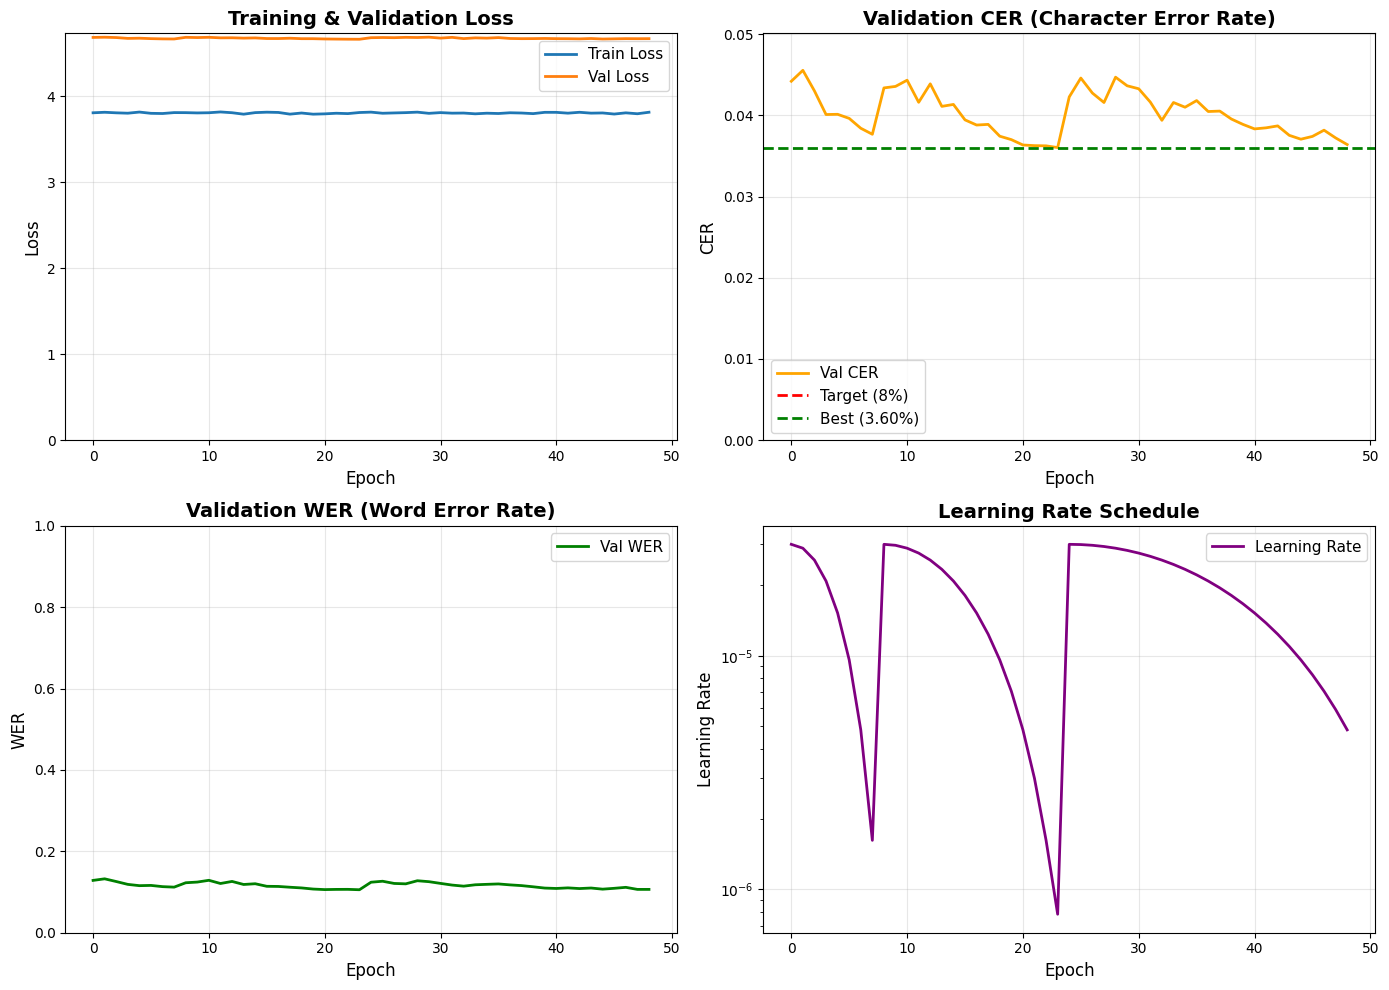


📊 TRAINING SUMMARY
Total Epochs: 49

📉 Loss:
   Final Train Loss: 3.8164
   Final Val Loss:   4.6728
   Best Val Loss:    4.6657 (Epoch 24)

📊 CER (Character Error Rate):
   Final Val CER: 0.0364 (96.4% acc)
   Best Val CER:  0.0360 (96.4% acc) ← SAVED MODEL
   Best Epoch:    24

📊 WER (Word Error Rate):
   Final Val WER: 0.1065
   Best Val WER:  0.1056 (Epoch 24)

🎯 Learning Rate:
   Initial LR:  3.00e-05
   Final LR:    4.82e-06

✅ Model saved at: '/kaggle/working/best_encoder_decoder.pth'
✅ Training curves saved at: '/kaggle/working/training_curves.png'


In [10]:
# Plot training history
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Loss curves
axes[0, 0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_ylim(bottom=0)

# Plot 2: CER curve
axes[0, 1].plot(history['val_cer'], label='Val CER', color='orange', linewidth=2)
axes[0, 1].axhline(y=0.08, color='red', linestyle='--', linewidth=2, label='Target (8%)')
axes[0, 1].axhline(y=best_val_cer, color='green', linestyle='--', linewidth=2, label=f'Best ({best_val_cer:.2%})')
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('CER', fontsize=12)
axes[0, 1].set_title('Validation CER (Character Error Rate)', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim(bottom=0, top=min(1.0, max(history['val_cer']) * 1.1))

# Plot 3: WER curve
axes[1, 0].plot(history['val_wer'], label='Val WER', color='green', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('WER', fontsize=12)
axes[1, 0].set_title('Validation WER (Word Error Rate)', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim(bottom=0, top=1.0)

# Plot 4: Learning Rate
axes[1, 1].plot(history['lr'], label='Learning Rate', color='purple', linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Learning Rate', fontsize=12)
axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150, bbox_inches='tight')
print("✅ Saved training curves to '/kaggle/working/training_curves.png'")
plt.show()

# Print summary statistics
print(f"\n{'='*60}")
print("📊 TRAINING SUMMARY")
print(f"{'='*60}")
print(f"Total Epochs: {len(history['train_loss'])}")
print(f"\n📉 Loss:")
print(f"   Final Train Loss: {history['train_loss'][-1]:.4f}")
print(f"   Final Val Loss:   {history['val_loss'][-1]:.4f}")
print(f"   Best Val Loss:    {min(history['val_loss']):.4f} (Epoch {history['val_loss'].index(min(history['val_loss']))+1})")

print(f"\n📊 CER (Character Error Rate):")
print(f"   Final Val CER: {history['val_cer'][-1]:.4f} ({(1-history['val_cer'][-1])*100:.1f}% acc)")
print(f"   Best Val CER:  {best_val_cer:.4f} ({(1-best_val_cer)*100:.1f}% acc) ← SAVED MODEL")
print(f"   Best Epoch:    {history['val_cer'].index(best_val_cer)+1}")

print(f"\n📊 WER (Word Error Rate):")
print(f"   Final Val WER: {history['val_wer'][-1]:.4f}")
print(f"   Best Val WER:  {min(history['val_wer']):.4f} (Epoch {history['val_wer'].index(min(history['val_wer']))+1})")

print(f"\n🎯 Learning Rate:")
print(f"   Initial LR:  {history['lr'][0]:.2e}")
print(f"   Final LR:    {history['lr'][-1]:.2e}")

print(f"\n✅ Model saved at: '/kaggle/working/best_encoder_decoder.pth'")
print(f"✅ Training curves saved at: '/kaggle/working/training_curves.png'")
print('='*60)

## 🧪 8. Test & Visualize

✅ Loaded best model from epoch 24 with CER 0.0360


Testing on Val: 100%|██████████| 173/173 [00:19<00:00,  8.94it/s]



Test Results:
  📉 Test Loss: 4.6657
  📊 Test CER:  0.0360 (96.4% acc)
  📊 Test WER:  0.1056


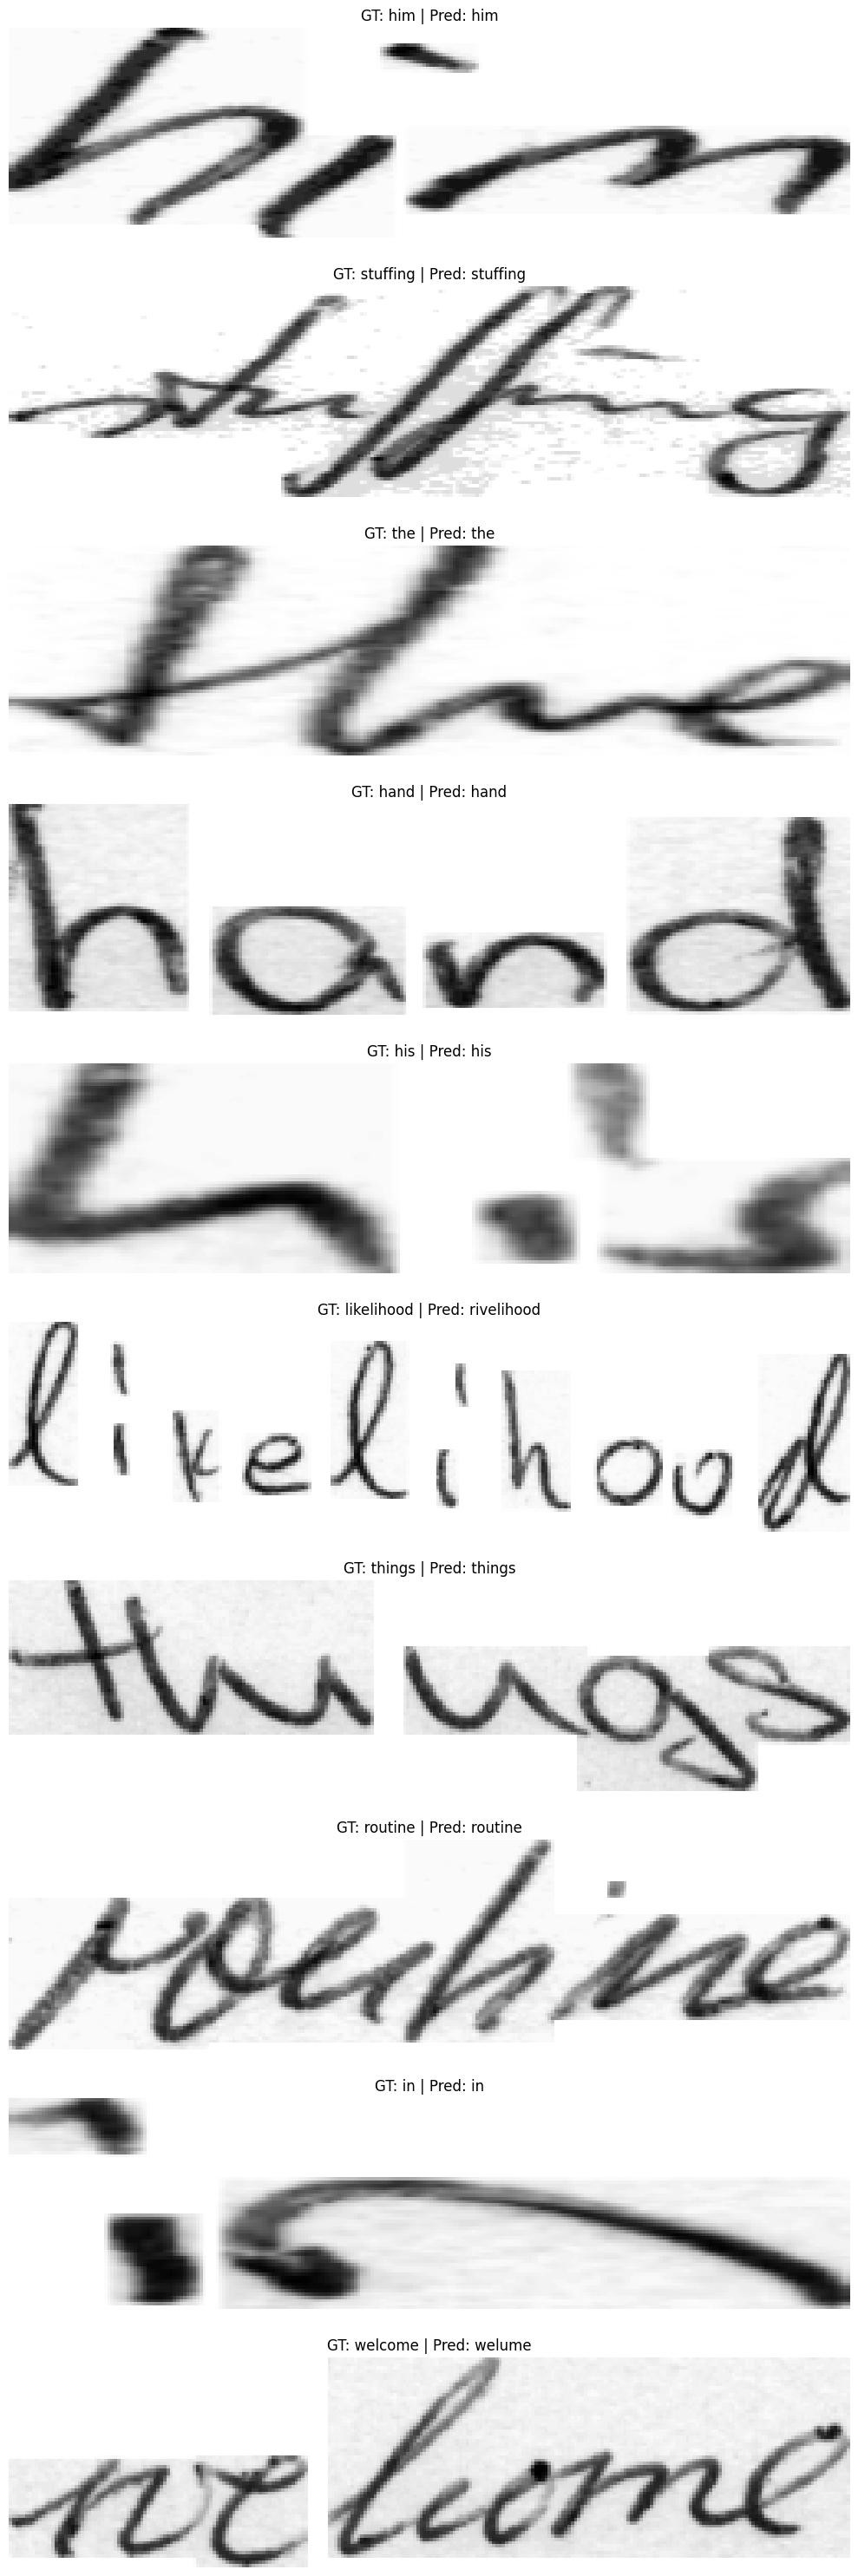

In [11]:
import random
import os

# Load best model
checkpoint_path = '/kaggle/working/best_encoder_decoder.pth'
checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded best model from epoch {checkpoint['epoch']} with CER {checkpoint['val_cer']:.4f}")

# Evaluate on validation set
model.eval()
val_loss = 0
all_predictions = []
all_targets = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Testing on Val"):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        
        # Teacher forcing for loss
        tgt_input = labels[:, :-1]
        tgt_output = labels[:, 1:]
        seq_len = tgt_input.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(seq_len).to(DEVICE)
        tgt_key_padding_mask = (tgt_input == PAD_IDX)
        
        logits = model(images, tgt_input, tgt_mask=tgt_mask,
                      tgt_key_padding_mask=tgt_key_padding_mask)
        loss = criterion(logits.reshape(-1, len(vocab)), tgt_output.reshape(-1))
        val_loss += loss.item()
        
        # Greedy decoding for metrics
        predictions = model.generate(images, SOS_IDX, EOS_IDX, max_len=50)
        all_predictions.extend(predictions)
        all_targets.extend(labels)

val_loss /= len(val_loader)
val_cer, val_wer = calculate_metrics(all_predictions, all_targets, idx_to_char)

print(f"\n{'='*60}")
print("Test Results:")
print(f"{'='*60}")
print(f"  📉 Test Loss: {val_loss:.4f}")
print(f"  📊 Test CER:  {val_cer:.4f} ({(1-val_cer)*100:.1f}% acc)")
print(f"  📊 Test WER:  {val_wer:.4f}")
print('='*60)

# Visualize 10 random samples
num_samples = 10
indices = random.sample(range(len(val_dataset)), num_samples)

fig, axes = plt.subplots(num_samples, 1, figsize=(10, 3*num_samples))
for i, idx in enumerate(indices):
    img, label = val_dataset[idx]
    img_tensor = img.unsqueeze(0).to(DEVICE)  # [1, 1, H, W]
    
    with torch.no_grad():
        pred = model.generate(img_tensor, SOS_IDX, EOS_IDX, max_len=50)[0]
    
    gt_text = decode_sequence(label, idx_to_char)
    pred_text = decode_sequence(pred, idx_to_char)
    
    # Plot image
    axes[i].imshow(img.squeeze(0).numpy(), cmap='gray')
    axes[i].set_title(f"GT: {gt_text} | Pred: {pred_text}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## 🔤 9. Test on EMNIST Single Characters (Out-of-Training)

Test model's ability to recognize **single characters** using EMNIST samples that were **NOT in training set**.

🔤 TESTING ON EMNIST SINGLE CHARACTERS (Out-of-Training)
Testing model on single character recognition (not seen in training)
✅ EMNIST test set loaded: 116,323 samples
✅ Sampled 510 test characters (25 per digit, 10 per letter)


Testing EMNIST: 100%|██████████| 510/510 [00:06<00:00, 75.33it/s]



EMNIST Single Character Test Results:
  📊 Overall Accuracy: 446/510 = 87.45%

  📊 Per-character accuracy:

     Digits (0-9): 243/250 = 97.2%
       0: 23/25 = 92.0%
       1: 25/25 = 100.0%
       2: 24/25 = 96.0%
       3: 25/25 = 100.0%
       4: 25/25 = 100.0%
       5: 25/25 = 100.0%
       6: 25/25 = 100.0%
       7: 25/25 = 100.0%
       8: 25/25 = 100.0%
       9: 21/25 = 84.0%

     Letters (a-z): 203/260 = 78.1%
       a: 8/10 = 80.0%
       b: 8/10 = 80.0%
       c: 10/10 = 100.0%
       d: 9/10 = 90.0%
       e: 10/10 = 100.0%
       f: 9/10 = 90.0%
       g: 5/10 = 50.0%
       h: 10/10 = 100.0%
       i: 4/10 = 40.0%
       j: 9/10 = 90.0%
       k: 9/10 = 90.0%
       l: 1/10 = 10.0%
       m: 10/10 = 100.0%
       n: 9/10 = 90.0%
       o: 2/10 = 20.0%
       p: 9/10 = 90.0%
       q: 3/10 = 30.0%
       r: 7/10 = 70.0%
       s: 8/10 = 80.0%
       t: 10/10 = 100.0%
       u: 10/10 = 100.0%
       v: 8/10 = 80.0%
       w: 10/10 = 100.0%
       x: 9/10 = 90.0%
       

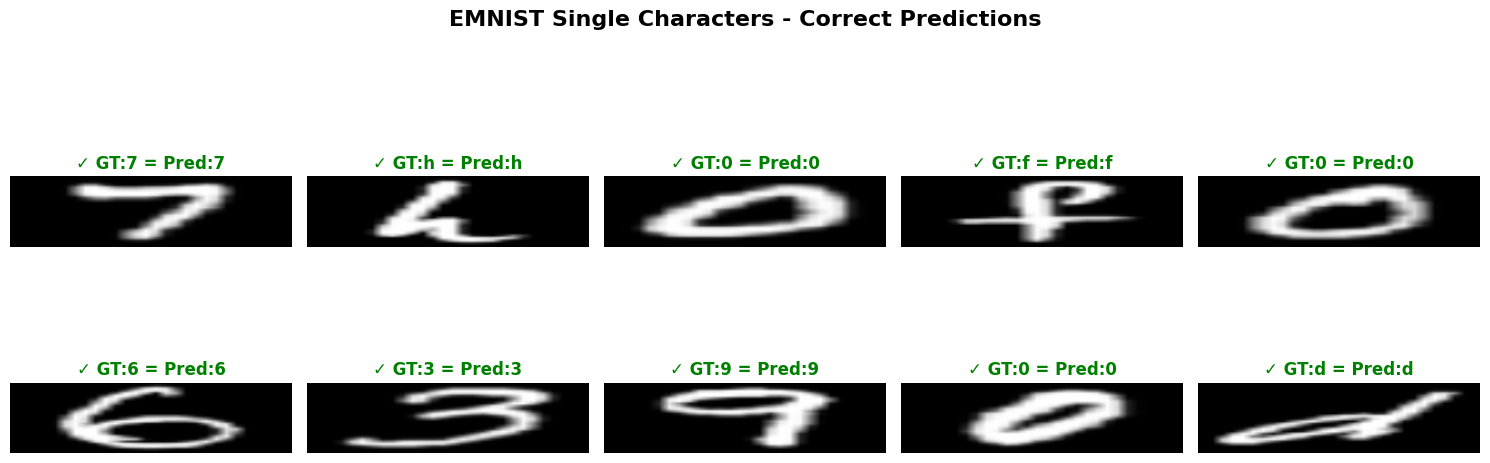


❌ Showing 10 WRONG predictions:


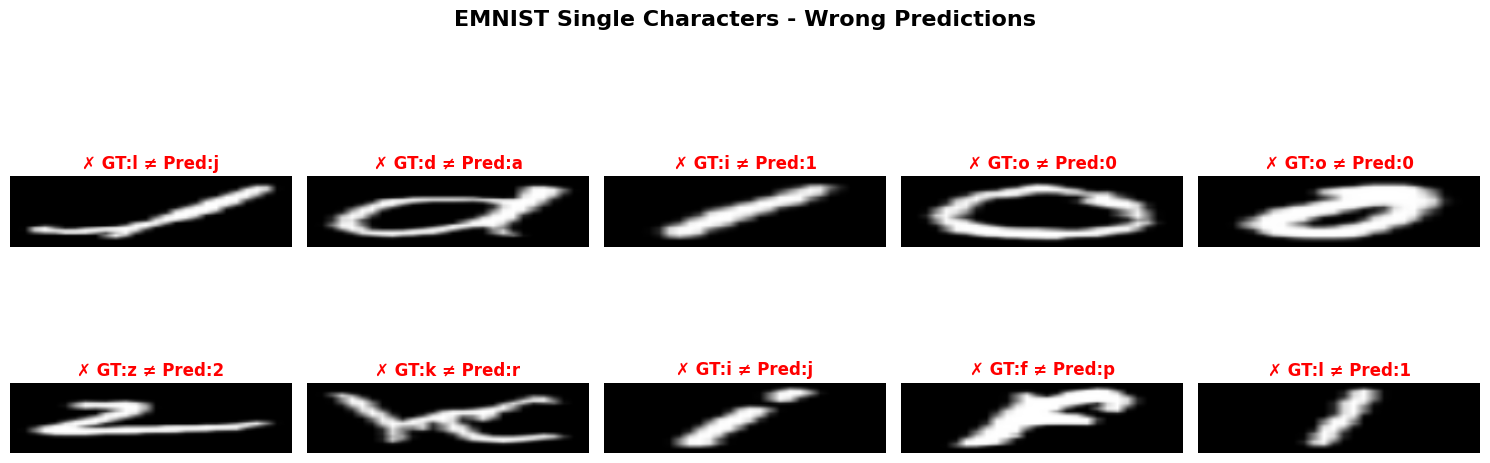


💡 Interpretation:
   - Model was trained mainly on WORDS (IAM)
   - EMNIST single chars were auxiliary (4996 samples)
   - This test shows BONUS capability on single character recognition
   - High accuracy here means model can handle both words AND single chars!


In [12]:
print('='*60)
print('🔤 TESTING ON EMNIST SINGLE CHARACTERS (Out-of-Training)')
print('='*60)
print('Testing model on single character recognition (not seen in training)')

import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
from torchvision import datasets
from collections import defaultdict
from tqdm import tqdm
import random

# --- FIX: Patch URL EMNIST để tránh lỗi download ---
datasets.EMNIST.url = 'https://biometrics.nist.gov/cs_links/EMNIST/gzip.zip'

try:
    # Load EMNIST test set (different from training)
    emnist_test_data = datasets.EMNIST(
        root='./data',
        split='byclass',
        train=False,  # Use TEST set (not in training)
        download=True
    )
    
    print(f'✅ EMNIST test set loaded: {len(emnist_test_data):,} samples')
    
    # Sample 500 test characters (balanced)
    emnist_to_char = {}
    for i in range(10):
        emnist_to_char[i] = str(i)
    for i in range(26):
        emnist_to_char[36 + i] = chr(ord('a') + i)
    
    class_samples = defaultdict(list)
    for idx in range(len(emnist_test_data)):
        # Chỉ lấy mẫu nếu label nằm trong digit hoặc lowercase letter (bỏ qua Uppercase để khớp vocab)
        img, label = emnist_test_data[idx]
        if label in emnist_to_char:
            class_samples[label].append(idx)
    
    # Sample 250 digits + 250 letters = 500 total
    random.seed(123)  # Different seed from training
    test_indices = []
    
    # 250 digits (25 per digit)
    for label in range(10):
        if label in class_samples:
            selected = random.sample(class_samples[label], min(25, len(class_samples[label])))
            test_indices.extend(selected)
    
    # 250 letters (9-10 per letter)
    for label in range(36, 62):
        if label in class_samples:
            selected = random.sample(class_samples[label], min(10, len(class_samples[label])))
            test_indices.extend(selected)
    
    random.shuffle(test_indices)
    
    print(f'✅ Sampled {len(test_indices)} test characters (25 per digit, 10 per letter)')
    
    # Test on EMNIST
    model.eval()
    correct = 0
    total = 0
    per_class_correct = defaultdict(int)
    per_class_total = defaultdict(int)
    predictions_list = []
    
    with torch.no_grad():
        for idx in tqdm(test_indices, desc='Testing EMNIST'):
            img, label = emnist_test_data[idx]
            gt_char = emnist_to_char[label]
            
            # Preprocess EMNIST image
            img_np = np.array(img)
            img_np = np.rot90(img_np, k=-1)
            img_np = np.fliplr(img_np)
            img_np = cv2.resize(img_np, (IMG_W, IMG_H))
            
            # Normalize & Tensor
            img_norm = img_np.astype(np.float32) / 255.0
            img_tensor = torch.FloatTensor(img_norm).unsqueeze(0).unsqueeze(0).to(DEVICE)  # [1, 1, H, W]
            
            # Predict
            pred = model.generate(img_tensor, SOS_IDX, EOS_IDX, max_len=50)[0]
            pred_text = decode_sequence(pred, idx_to_char)
            
            # Check correctness
            is_correct = (pred_text == gt_char)
            correct += int(is_correct)
            total += 1
            
            per_class_total[gt_char] += 1
            per_class_correct[gt_char] += int(is_correct)
            
            predictions_list.append((img_np, gt_char, pred_text, is_correct))
    
    # Calculate metrics
    accuracy = correct / total * 100
    
    # --- FIX SYNTAX ERROR HERE (Use double quotes outside) ---
    print(f"\n{'='*60}")
    print('EMNIST Single Character Test Results:')
    print(f"{'='*60}")
    print(f'  📊 Overall Accuracy: {correct}/{total} = {accuracy:.2f}%')
    
    # Per-class accuracy
    print(f'\n  📊 Per-character accuracy:')
    
    # Digits
    digit_correct = sum(per_class_correct[str(i)] for i in range(10))
    digit_total = sum(per_class_total[str(i)] for i in range(10))
    digit_acc = (digit_correct/digit_total*100) if digit_total > 0 else 0
    print(f'\n     Digits (0-9): {digit_correct}/{digit_total} = {digit_acc:.1f}%')
    
    for i in range(10):
        char = str(i)
        acc = per_class_correct[char] / per_class_total[char] * 100 if per_class_total[char] > 0 else 0
        print(f'       {char}: {per_class_correct[char]}/{per_class_total[char]} = {acc:.1f}%')
    
    # Letters
    letter_correct = sum(per_class_correct[chr(ord('a')+i)] for i in range(26))
    letter_total = sum(per_class_total[chr(ord('a')+i)] for i in range(26))
    letter_acc = (letter_correct/letter_total*100) if letter_total > 0 else 0
    print(f'\n     Letters (a-z): {letter_correct}/{letter_total} = {letter_acc:.1f}%')
    
    for i in range(26):
        char = chr(ord('a') + i)
        acc = per_class_correct[char] / per_class_total[char] * 100 if per_class_total[char] > 0 else 0
        print(f'       {char}: {per_class_correct[char]}/{per_class_total[char]} = {acc:.1f}%')
    
    print(f"\n{'='*60}")
    
    # Visualize samples (20 samples: 10 correct, 10 wrong)
    correct_samples = [p for p in predictions_list if p[3]]
    wrong_samples = [p for p in predictions_list if not p[3]]
    
    num_correct_show = min(10, len(correct_samples))
    num_wrong_show = min(10, len(wrong_samples))
    
    if num_correct_show > 0:
        print(f'\n✅ Showing {num_correct_show} CORRECT predictions:')
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        axes = axes.flatten()
        
        for i in range(num_correct_show):
            img, gt, pred, _ = correct_samples[i]
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(f'✓ GT:{gt} = Pred:{pred}', color='green', fontweight='bold')
            axes[i].axis('off')
        
        for i in range(num_correct_show, 10):
            axes[i].axis('off')
        
        plt.suptitle('EMNIST Single Characters - Correct Predictions', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    if num_wrong_show > 0:
        print(f'\n❌ Showing {num_wrong_show} WRONG predictions:')
        fig, axes = plt.subplots(2, 5, figsize=(15, 6))
        axes = axes.flatten()
        
        for i in range(num_wrong_show):
            img, gt, pred, _ = wrong_samples[i]
            axes[i].imshow(img, cmap='gray')
            axes[i].set_title(f'✗ GT:{gt} ≠ Pred:{pred}', color='red', fontweight='bold')
            axes[i].axis('off')
        
        for i in range(num_wrong_show, 10):
            axes[i].axis('off')
        
        plt.suptitle('EMNIST Single Characters - Wrong Predictions', fontsize=16, fontweight='bold')
        plt.tight_layout()
        plt.show()
    
    print(f'\n💡 Interpretation:')
    print(f'   - Model was trained mainly on WORDS (IAM)')
    trained_chars = len(emnist_images) if "emnist_images" in globals() else 5000
    print(f'   - EMNIST single chars were auxiliary ({trained_chars} samples)')
    print(f'   - This test shows BONUS capability on single character recognition')
    print(f'   - High accuracy here means model can handle both words AND single chars!')

except Exception as e:
    print(f'⚠️  EMNIST test failed: {e}')
    import traceback
    traceback.print_exc()
    print(f'   Skipping single character test...')

🔄 Loading best model checkpoint...
✅ Loaded model from Epoch 24 (CER: 0.0360)

1️⃣ PHÂN TÍCH TẬP KIỂM THỬ (VAL/TEST)
🔍 Đang quét lỗi trên tập Validation (8274 mẫu)...


Evaluating Validation: 100%|██████████| 173/173 [00:16<00:00, 10.38it/s]


❌ Tìm thấy tổng cộng 874 mẫu sai trong tập Validation.


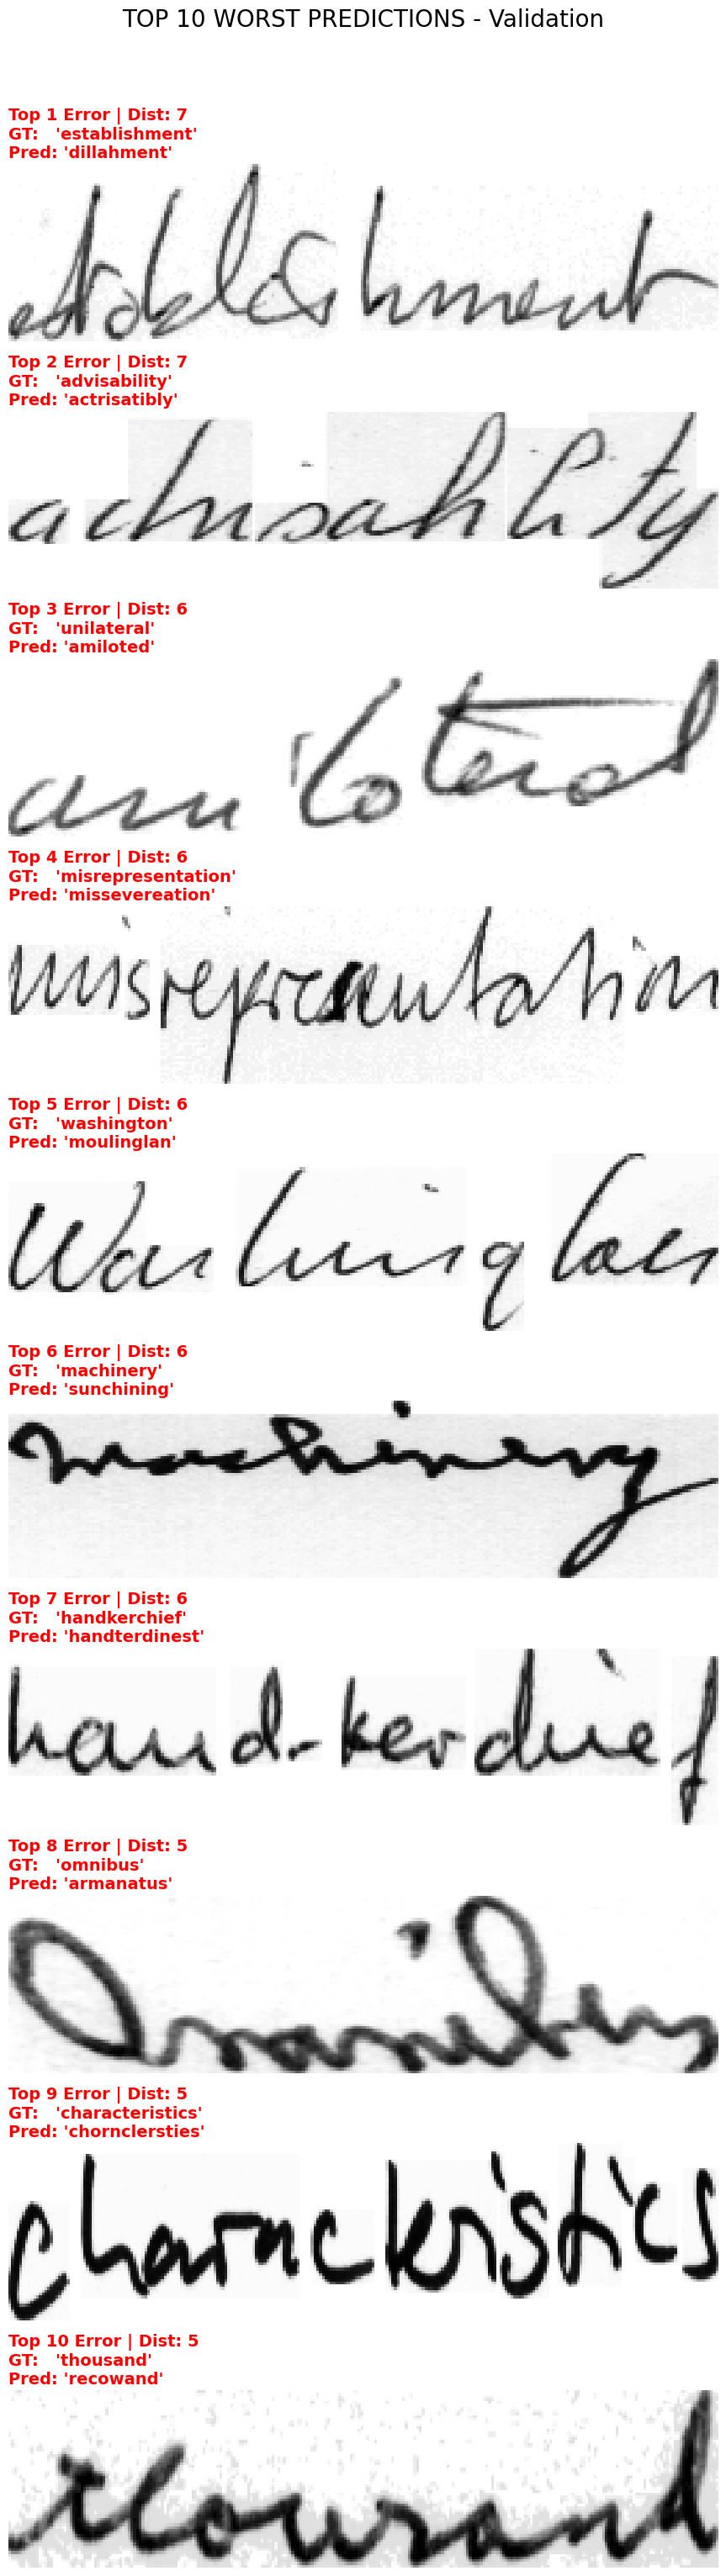


2️⃣ PHÂN TÍCH TẬP HUẤN LUYỆN (TRAIN)
⚠️ Lưu ý: Quá trình này có thể mất 10-20 phút do tập Train lớn (~75k mẫu)
🔍 Đang quét lỗi trên tập Training (79455 mẫu)...


Evaluating Training: 100%|██████████| 1656/1656 [03:02<00:00,  9.07it/s]


❌ Tìm thấy tổng cộng 218 mẫu sai trong tập Training.


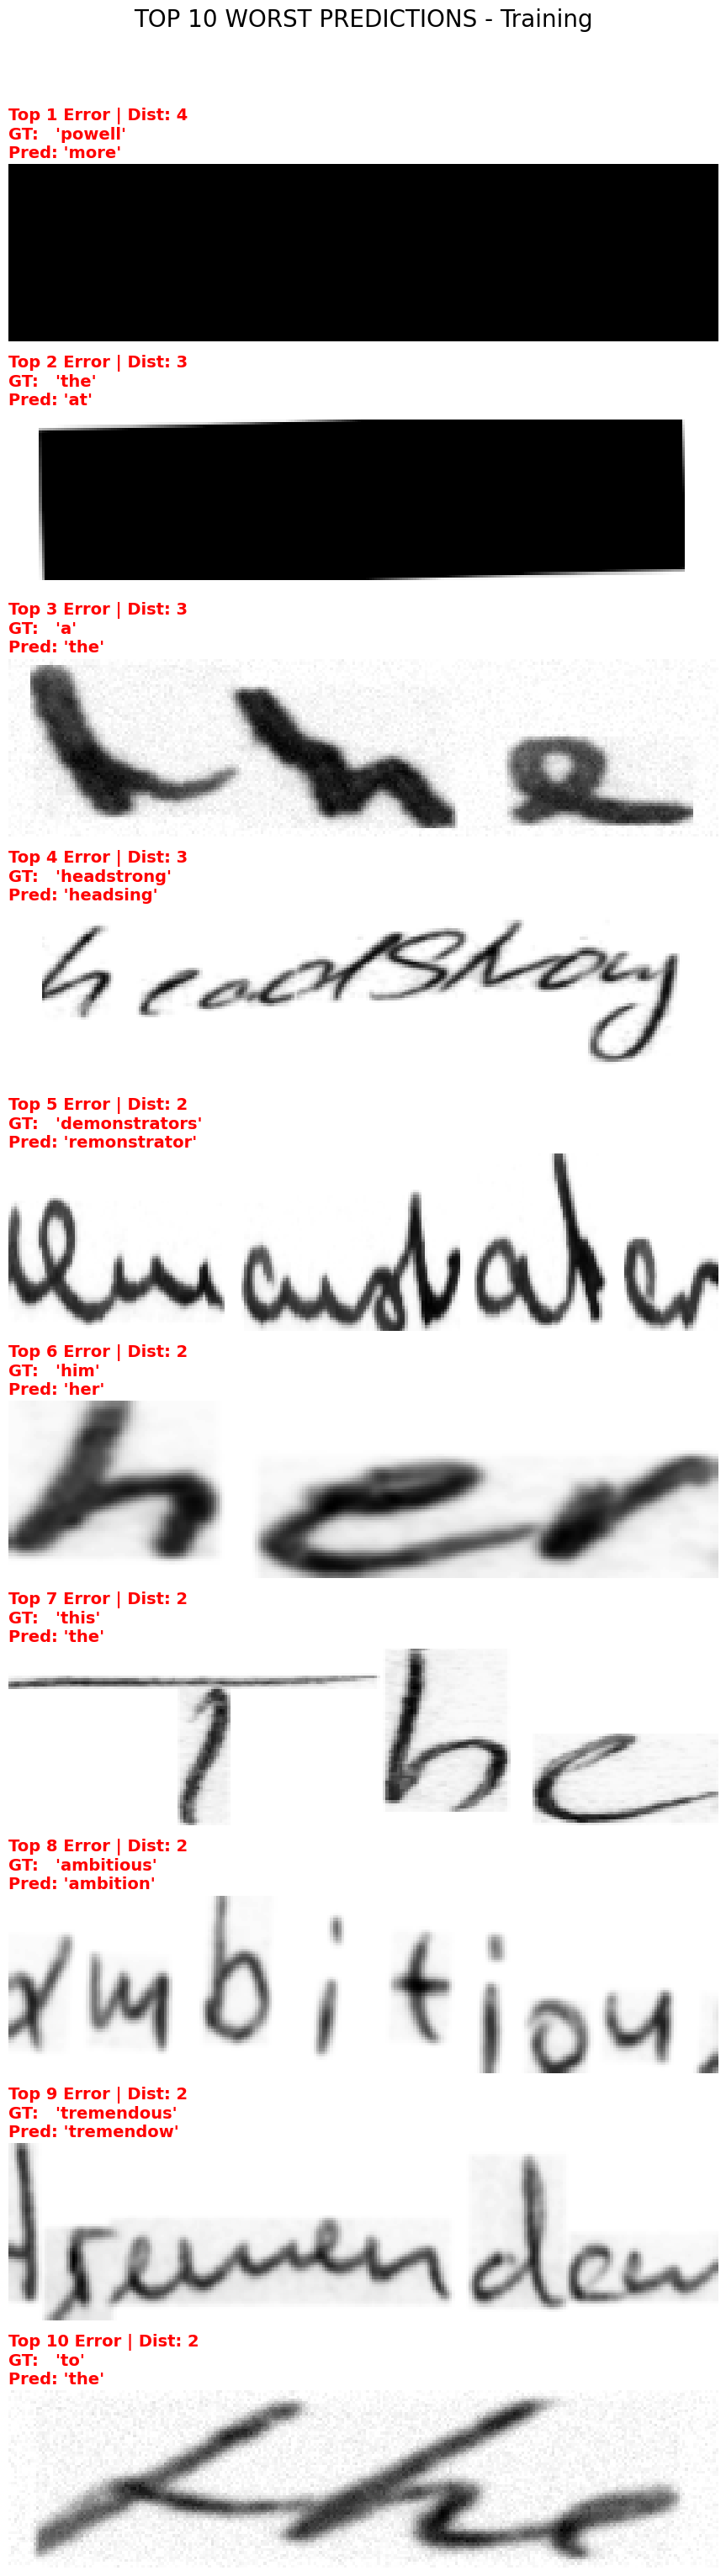

In [13]:
# ===========================================================
# 🧪 10. ERROR ANALYSIS: FIND TOP WORST PREDICTIONS
# ===========================================================
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

def get_worst_samples(model, loader, idx_to_char, device, top_k=10, name="Dataset"):
    """
    Chạy model trên toàn bộ loader, tìm các mẫu sai và trả về top_k mẫu sai tệ nhất.
    """
    model.eval()
    errors = []
    
    print(f"🔍 Đang quét lỗi trên tập {name} ({len(loader.dataset)} mẫu)...")
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc=f"Evaluating {name}"):
            images = images.to(device)
            
            # Sinh dự đoán (Greedy Search)
            preds = model.generate(images, SOS_IDX, EOS_IDX, max_len=50)
            
            # Decode batch
            for i in range(len(images)):
                gt_text = decode_sequence(labels[i], idx_to_char)
                pred_text = decode_sequence(preds[i], idx_to_char)
                
                # Chỉ lưu nếu dự đoán sai
                if gt_text != pred_text:
                    # Tính khoảng cách chỉnh sửa (Levenshtein) để biết sai nhiều hay ít
                    dist = levenshtein_distance(gt_text, pred_text)
                    
                    # Lưu lại thông tin (chuyển ảnh về CPU để tiết kiệm GPU RAM)
                    # Chỉ lưu ảnh nếu cần thiết để tránh tràn RAM hệ thống với tập Train lớn
                    # Ở đây ta lưu tensor cpu nhỏ gọn
                    errors.append({
                        'img': images[i].cpu(),
                        'gt': gt_text,
                        'pred': pred_text,
                        'dist': dist
                    })
    
    # Sắp xếp theo khoảng cách lỗi giảm dần (sai nhiều nhất lên đầu)
    errors.sort(key=lambda x: x['dist'], reverse=True)
    
    print(f"❌ Tìm thấy tổng cộng {len(errors)} mẫu sai trong tập {name}.")
    return errors[:top_k]

def plot_top_errors(errors_list, name="Dataset"):
    """Vẽ hình các mẫu sai"""
    if not errors_list:
        print(f"🎉 Chúc mừng! Không tìm thấy lỗi nào trong tập {name}!")
        return

    count = len(errors_list)
    fig, axes = plt.subplots(count, 1, figsize=(12, 3 * count))
    if count == 1: axes = [axes] # Fix lỗi nếu chỉ có 1 mẫu
    
    for i, err in enumerate(errors_list):
        # Chuyển tensor ảnh về numpy để vẽ (1, H, W) -> (H, W)
        img = err['img'].squeeze(0).numpy()
        
        # Đảm bảo ảnh hiển thị rõ (đảo ngược màu nếu cần hoặc normalize)
        img = np.clip(img, 0, 1)

        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(
            f"Top {i+1} Error | Dist: {err['dist']}\n"
            f"GT:   '{err['gt']}'\n"
            f"Pred: '{err['pred']}'",
            fontsize=14, color='red', fontweight='bold', loc='left'
        )
        axes[i].axis('off')
    
    plt.suptitle(f"TOP {count} WORST PREDICTIONS - {name}", fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()

# --- THỰC THI ---

# 1. Load lại trọng số tốt nhất (Best Model)
print("🔄 Loading best model checkpoint...")
checkpoint = torch.load('/kaggle/working/best_encoder_decoder.pth', map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✅ Loaded model from Epoch {checkpoint['epoch']} (CER: {checkpoint['val_cer']:.4f})")

# 2. Phân tích tập Test/Validation (Nhanh)
print("\n" + "="*60)
print("1️⃣ PHÂN TÍCH TẬP KIỂM THỬ (VAL/TEST)")
print("="*60)
val_worst = get_worst_samples(model, val_loader, idx_to_char, DEVICE, top_k=10, name="Validation")
plot_top_errors(val_worst, name="Validation")

# 3. Phân tích tập Train (Lâu hơn do dữ liệu lớn)
print("\n" + "="*60)
print("2️⃣ PHÂN TÍCH TẬP HUẤN LUYỆN (TRAIN)")
print("⚠️ Lưu ý: Quá trình này có thể mất 10-20 phút do tập Train lớn (~75k mẫu)")
print("="*60)
# Sử dụng train_loader hiện có
train_worst = get_worst_samples(model, train_loader, idx_to_char, DEVICE, top_k=10, name="Training")
plot_top_errors(train_worst, name="Training")